# Round 3 Volatility Smile

Compute implied volatility per `VEV_*` voucher from historical mids, plot IV against log-moneyness, and overlay a parabolic fit. Mirrors the `option-smile` pipeline from the `imc-qtc-3` repo so the README can reference a generated figure.

In [1]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "assets").is_dir():
            return candidate
    raise FileNotFoundError("Could not find repo root (expected data/ and assets/)")


ROOT = find_repo_root(Path.cwd().resolve())
ROUND = 3
INITIAL_TTE_DAYS = 5
DAYS_PER_YEAR = 365
TIMESTAMPS_PER_DAY = 1_000_000
UNDERLYING = "VELVETFRUIT_EXTRACT"
VOUCHER_STRIKES = {
    "VEV_4000": 4000,
    "VEV_4500": 4500,
    "VEV_5000": 5000,
    "VEV_5100": 5100,
    "VEV_5200": 5200,
    "VEV_5300": 5300,
    "VEV_5400": 5400,
    "VEV_5500": 5500,
    "VEV_6000": 6000,
    "VEV_6500": 6500,
}
OUT_PATH = ROOT / "assets" / "extra" / "Round-3-Volatility-Smile.png"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

In [2]:
def load_round(round_num: int) -> pd.DataFrame:
    round_dir = ROOT / "data" / f"Round-{round_num}"
    files = sorted(
        round_dir.glob("prices_round_*_day_*.csv"),
        key=lambda p: int(re.search(r"day_(-?\d+)", p.stem).group(1)),
    )
    if not files:
        raise FileNotFoundError(f"No price CSVs found in {round_dir}")

    frames = [pd.read_csv(f, sep=";") for f in files]
    combined = pd.concat(frames, ignore_index=True)

    both = combined["bid_price_1"].notna() & combined["ask_price_1"].notna()
    combined.loc[both, "mid_price"] = (
        combined.loc[both, "bid_price_1"] + combined.loc[both, "ask_price_1"]
    ) / 2
    combined = combined.dropna(subset=["mid_price"])
    combined = combined[combined["mid_price"] > 0]

    day_order = {d: i for i, d in enumerate(sorted(combined["day"].unique()))}
    combined["global_t"] = (
        combined["day"].map(day_order) * TIMESTAMPS_PER_DAY + combined["timestamp"]
    )
    return combined


prices = load_round(ROUND)
print(f"loaded {len(prices):,} rows across {prices['day'].nunique()} days")

loaded 360,000 rows across 3 days


In [3]:
def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_call(spot: float, strike: float, tte: float, sigma: float) -> float:
    if spot <= 0 or strike <= 0 or tte <= 0 or sigma <= 0:
        return max(0.0, spot - strike)
    sqrt_t = math.sqrt(tte)
    d1 = (math.log(spot / strike) + 0.5 * sigma * sigma * tte) / (sigma * sqrt_t)
    d2 = d1 - sigma * sqrt_t
    return spot * norm_cdf(d1) - strike * norm_cdf(d2)


def implied_vol(price: float, spot: float, strike: float, tte: float) -> float:
    intrinsic = max(0.0, spot - strike)
    if price <= intrinsic:
        return 1e-4
    low, high = 1e-6, 5.0
    for _ in range(100):
        mid = 0.5 * (low + high)
        model = bs_call(spot, strike, tte, mid)
        if abs(model - price) < 1e-5:
            return max(mid, 1e-4)
        if model < price:
            low = mid
        else:
            high = mid
    return max(0.5 * (low + high), 1e-4)


def tte_years(global_t: int) -> float:
    days_left = INITIAL_TTE_DAYS - global_t / TIMESTAMPS_PER_DAY
    return max(days_left, 1e-4) / DAYS_PER_YEAR


def fit_parabola(xs: np.ndarray, ys: np.ndarray):
    if len(xs) < 4:
        return None
    return np.polyfit(xs, ys, 2)

In [4]:
wide = prices.pivot_table(
    index=["day", "timestamp", "global_t"],
    columns="product",
    values="mid_price",
    aggfunc="first",
).dropna(subset=[UNDERLYING])


def smile_for_snapshot(row) -> pd.DataFrame:
    spot = row[UNDERLYING]
    tte = tte_years(row.name[2])
    sqrt_t = math.sqrt(tte)
    records = []
    for symbol, strike in VOUCHER_STRIKES.items():
        mid = row.get(symbol)
        if pd.isna(mid):
            continue
        iv = implied_vol(mid, spot, strike, tte)
        records.append(
            {
                "product": symbol,
                "strike": strike,
                "mid": mid,
                "moneyness": math.log(strike / spot) / sqrt_t,
                "implied_vol": iv,
                "fit_candidate": iv > 0.05 and mid >= 2.0,
            }
        )
    return pd.DataFrame(records)


all_smiles = []
for key, row in wide.iterrows():
    smile = smile_for_snapshot(row)
    if smile.empty:
        continue
    day, timestamp, global_t = key
    smile["day"] = day
    smile["timestamp"] = timestamp
    smile["global_t"] = global_t
    all_smiles.append(smile)

all_smiles = pd.concat(all_smiles, ignore_index=True)
print(f"computed IV for {len(all_smiles):,} (snapshot, voucher) pairs")

computed IV for 300,000 (snapshot, voucher) pairs


saved assets/extra/Round-3-Volatility-Smile.png
parabola: a=0.1001, b=-0.0004, c=0.3269


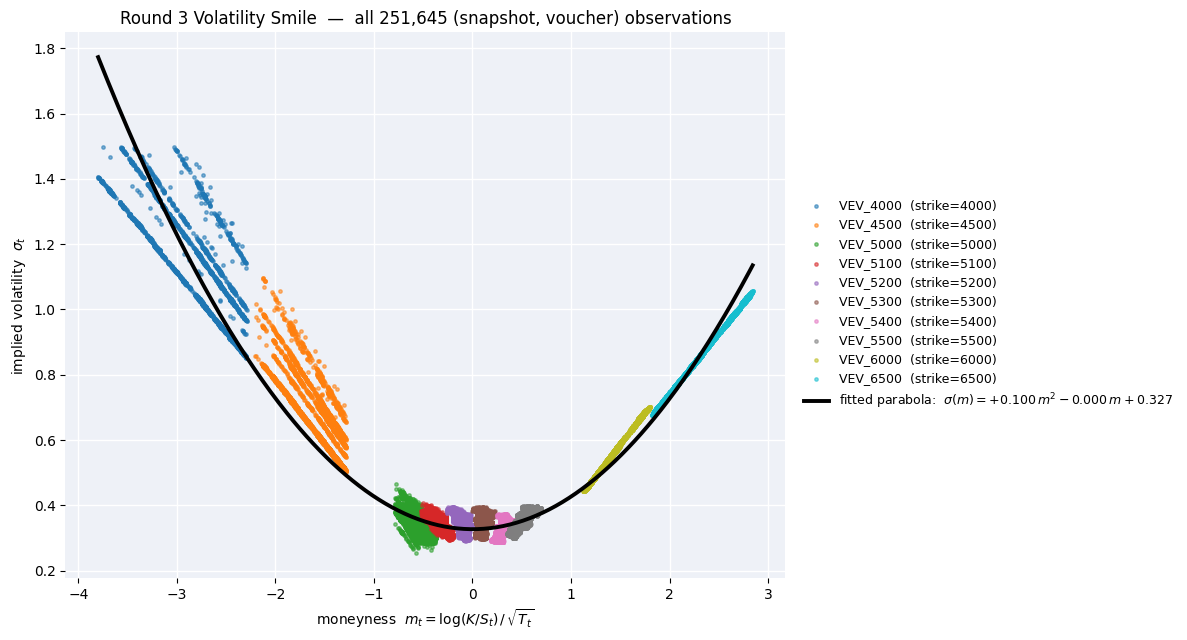

In [5]:
IV_FLOOR = 0.05
IV_CEIL = 1.5

cloud = all_smiles[
    (all_smiles["implied_vol"] > IV_FLOOR)
    & (all_smiles["implied_vol"] < IV_CEIL)
].copy()

strikes_in_cloud = sorted(cloud["strike"].unique())
cmap = plt.get_cmap("tab10")
strike_colors = {strike: cmap(i % 10) for i, strike in enumerate(strikes_in_cloud)}

coeffs = np.polyfit(cloud["moneyness"].to_numpy(), cloud["implied_vol"].to_numpy(), 2)
a, b, c = coeffs

fig, ax = plt.subplots(figsize=(12, 6.5))

for strike in strikes_in_cloud:
    sub = cloud[cloud["strike"] == strike]
    product = next(p for p, k in VOUCHER_STRIKES.items() if k == strike)
    ax.scatter(
        sub["moneyness"], sub["implied_vol"],
        s=6, color=strike_colors[strike], alpha=0.55,
        label=f"{product}  (strike={strike})",
    )

grid = np.linspace(cloud["moneyness"].min(), cloud["moneyness"].max(), 400)
ax.plot(
    grid, np.polyval(coeffs, grid),
    color="black", linewidth=2.8, zorder=5,
    label=f"fitted parabola:  $\\sigma(m) = {a:+.3f}\\,m^2 {b:+.3f}\\,m {c:+.3f}$",
)

ax.set_xlabel(r"moneyness  $m_t = \log(K/S_t)\,/\,\sqrt{T_t}$")
ax.set_ylabel(r"implied volatility  $\sigma_t$")
ax.set_title(
    f"Round 3 Volatility Smile  —  all {len(cloud):,} (snapshot, voucher) observations"
)
ax.set_facecolor("#eef1f7")
ax.grid(True, color="white", linewidth=1.0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), framealpha=0.0, fontsize=9)

fig.tight_layout()
fig.savefig(OUT_PATH, dpi=140, bbox_inches="tight")
print(f"saved {OUT_PATH.relative_to(ROOT)}")
print(f"parabola: a={a:.4f}, b={b:.4f}, c={c:.4f}")
plt.show()